## 1. Import Necessary Packages

In [1]:
import whisper
from transformers import AutoTokenizer, AutoModel
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms
import torchaudio
import numpy as np
import kaggle
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from typing import Literal
import gc
import librosa
import threading
from concurrent.futures import ThreadPoolExecutor, as_completed

d:\anaconda3\envs\ai-genre\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Define Default Values

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")
dataFolder = './data'
dataPath = Path(dataFolder)

Using: cuda


## 3. Download Data
In this, I will be using the [FMA Medium dataset](https://www.kaggle.com/datasets/imsparsh/fma-free-music-archive-small-medium).
Ensure that you have set your kaggle api token as an environment variable (KAGGLE_API_TOKEN) amd have enough storage for this dataset (34.26 GB).
I made this automatically check if the `./data` folder exists and skips the download if it does to prevent repeated downloadeds, to avoid this, just delete the `./data` folder when you need to redownload.

In [3]:
if not dataPath.exists():
    kaggle.api.authenticate()
    kaggle.api.dataset_download_files('imsparsh/fma-free-music-archive-small-medium', path=dataFolder, unzip=True)

## 4. Clean and Prepare Data
Get genre names and create Dataset class to read the files. Rather than loading all 34GB into memory, this will pull the files at read time.

### Load Metadata

In [4]:
def load_fma_dataset(data_folder: str, subset: Literal['small', 'medium'] = 'medium'):
    """
    Loads FMA dataset from files to in-memory based on the subsets.

        Args:
            data_folder (string): The location that the FMA data is in
            subset ('small' | 'medium'): The dataset to be loaded

        Returns: 
            pd.DataFrame with the following columns:
                track_id - file name without the .mp3
                filepath - absolute path to the file
                genre_id - corresponding genre id from genres.csv
                split - testing, training, or validation split
                label - the output label for the genre_id
                genre_title - the full name for the genre, i.e. Electronic
    """
    genres_df = pd.read_csv(f'{data_folder}/fma_metadata/genres.csv', index_col=0)
    print(genres_df.describe)
    
    tracks_df = pd.read_csv(f'{data_folder}/fma_metadata/tracks.csv', index_col=0, header=[0, 1])

    # The FMA dataset has predetermined test/train/val splits and sizes
    subset_mask = tracks_df['set', 'subset'] == subset
    tracks_df = tracks_df[subset_mask]

    rows = []
    for track_id, row in tracks_df.iterrows():
        # file naming: folder name (3 digits) + track id (3 digits) -> unique file name (6 digits)
        id_str = str(track_id).zfill(6)
        folder = id_str[:3]
        filename = id_str + '.mp3'
        filepath = Path(data_folder) / f"fma_{subset}" / f"fma_{subset}" / folder / filename

        if not filepath.exists():
            continue
            
        genre_id = row['track', 'genre_top']
        split: Literal['training', 'validation', 'test'] = row['set', 'split']
        file_path = str(filepath.resolve()).replace(r'\\', r'\\\\')
        rows.append({
            'track_id': id_str,
            'filepath': file_path,
            'genre_id': genre_id,
            'split': split
        })

    df = pd.DataFrame(rows)

    # Map genre_id to integer label [0, N)
    unique_genres = sorted(df['genre_id'].dropna().unique())
    genre_to_idx = {g: i for i, g in enumerate(unique_genres)}
    df['label'] = df['genre_id'].map(genre_to_idx)

    df['genre_title'] = df['genre_id'].map(genres_df['title'])

    return df, genre_to_idx

df, genre_map = load_fma_dataset(dataFolder)

print("Genres:")
for g, i in genre_map.items():
    print(f'{i+1}. {g}, label={i}')

<bound method NDFrame.describe of           #tracks  parent          title  top_level
genre_id                                           
1            8693      38    Avant-Garde         38
2            5271       0  International          2
3            1752       0          Blues          3
4            4126       0           Jazz          4
5            4106       0      Classical          5
...           ...     ...            ...        ...
1032           60     102        Turkish          2
1060           30      46          Tango          2
1156           26     130           Fado          2
1193           72     763      Christmas         38
1235        14938       0   Instrumental       1235

[163 rows x 4 columns]>
Genres:
1. Blues, label=0
2. Classical, label=1
3. Country, label=2
4. Easy Listening, label=3
5. Electronic, label=4
6. Experimental, label=5
7. Folk, label=6
8. Hip-Hop, label=7
9. Instrumental, label=8
10. International, label=9
11. Jazz, label=10
12. Old-Time /

### Create Custom Dataset

In [5]:
class CustomDataset(Dataset):
    def __init__(
            self, 
            df: pd.DataFrame,
            lyric_model: str,
            tokenizer: AutoTokenizer,
            automodel: AutoModel,
            sample_rate: int = 22050, 
            duration: float = 30.0, 
            n_mels: int = 128,
            n_bins: int = 84,
            bins_per_octave: int = 12,
            n_fft: int = 2048,
            hop_length: int = 512,
            cache_dir: str = None,
            spect_transform: transforms = None,
            lyric_transform: dict = None,
            num_workers: int = 0
        ):
        # dataset
        self.video_labels = df['label'].to_numpy()
        self.video_paths = df['filepath'].to_numpy()
        
        self.spect_transform = spect_transform
        self.lyric_transform = lyric_transform
        self.num_workers = num_workers

        # lyric related models and settings
        self.lyric_model = lyric_model
        self.tokenizer = tokenizer
        self.automodel = automodel

        # spectrogram values
        self.sample_rate = sample_rate
        self.duration = duration
        self.n_mels = n_mels
        self.n_bins = n_bins
        self.bins_per_octave = bins_per_octave
        self.n_fft = n_fft
        self.hop_length = hop_length

        # cache
        self.cache_dir = Path(cache_dir) if cache_dir else None
        if self.cache_dir:
            self.cache_dir.mkdir(parents=True, exist_ok=True)

        # stats
        self.spect_mean = [0.0, 0.0]
        self.spect_std = [0.0, 0.0]
        self.lyric_mean = 0.0
        self.lyric_std = 0.0

    def cache_idx(self, idx: int) -> bool:
        try:
            self.__getitem__(idx)
            return True
        except Exception as e:
            print(f'Failed to save {idx} : {self.video_paths[idx]}, {e}')
            return False

    def get_whisper_model(self):
        if not hasattr(thread_local, 'whisper'):
            thread_local.whisper = whisper.load_model(self.lyric_model)
        return thread_local.whisper

    def precache_all(self) -> list[str]:
        if not self.cache_dir:
            return []

        N = len(self.video_labels)
        success = [False] * N

        if self.num_workers > 0:
            with ThreadPoolExecutor(max_workers=self.num_workers) as executor:
                futures = {
                    executor.submit(self.cache_idx, i):i for i in range(N)
                }
                for future in tqdm(as_completed(futures), total=len(futures), desc="Caching"):
                    i = futures[future]
                    success[i] = future.result()
        
        else:
            for i in tqdm(range(N), total=N, desc="Caching"):
                success[i] = (self.cache_idx(i))

        self.video_labels = [self.video_labels[i] for i in range(N) if success[i]]
        self.video_paths = [self.video_paths[i] for i in range(N) if success[i]]
        return [i for i in range(N) if not success[i]]

    def calc_log_mel(self, audio: np.darray) -> np.darray:
        mel = librosa.feature.melspectrogram(
            y=audio,
            sr=self.sample_rate,
            n_mels=self.n_mels,
            n_fft=self.n_fft,
            hop_length=self.hop_length
        )
        log_mel = librosa.power_to_db(mel, ref=np.max)

        # Normalize to [0,1]
        log_mel = (log_mel-log_mel.min())/(log_mel.max()-log_mel.min() + 1e-8)
        return log_mel

    def calc_cqt(self, audio: np.darray) -> np.darray:
        cqt = librosa.cqt(
            y=audio,
            sr=self.sample_rate,
            n_bins = self.n_bins,
            bins_per_octave = self.bins_per_octave,
            hop_length=self.hop_length,
            fmin=librosa.note_to_hz('C1')
        )
        log_cqt = librosa.amplitude_to_db(np.abs(cqt), ref=np.max)

        # Normalize to [0,1] and pad cqt
        log_cqt = (log_cqt-log_cqt.min())/(log_cqt.max()-log_cqt.min()+1e-8)
        padded_cqt = np.pad(log_cqt, ((0, self.n_mels - self.n_bins), (0, 0)))
        return padded_cqt

    def mp3_to_spectrogram(self, path: str) -> np.ndarray:
        audio, _ = librosa.load(
            path,
            sr=self.sample_rate,
            duration=self.duration,
            mono=True
        )

        # Pad clip
        expected_samples = int(self.duration * self.sample_rate)
        if len(audio) < expected_samples:
            audio = np.pad(audio, (0, expected_samples - len(audio)))

        lm = self.calc_log_mel(audio)
        cqt = self.calc_cqt(audio)

        return np.stack([lm.astype(np.float32), cqt.astype(np.float32)])
    
    def mp3_to_lyrics(self, path: str) -> np.ndarray:
        try:
            audio = self.get_whisper_model().transcribe(path, fp16=False)
        except Exception as e:
            print(f"Error occurred transcribing audio: {path}, {e}")
        text = audio['text'].strip()
        if len(text.split()) < 5:
            text = "instrumental music"
        try:
            encoded = self.tokenizer(
                text,
                return_tensors='pt',
                truncation=True,
                max_length=512,
                padding='max_length'
            )
        except Exception as e:
            print(f"error occurred tokenizing the audio: {e}")
        # Move encoded output device to be the same as the automodel
        device = next(self.automodel.parameters()).device
        encoded = {k: v.to(device) for k, v in encoded.items()}
        with torch.no_grad():
            try:
                output: torch.Tensor = self.automodel(**encoded)
            except Exception as e:
                print(f"error occurred converting tokens to embeddings: {e}")
        embedding = output.last_hidden_state[:, 0, :]
        return embedding.cpu().numpy()
        

    def load_and_compute_spectrogram(self, path: str) -> np.ndarray:
        if self.cache_dir:
            cache_path = self.cache_dir / (Path(path).stem + "_spect_.npy")
            if cache_path.exists():
                return np.load(cache_path)
        
        spectrogram = self.mp3_to_spectrogram(path)

        if self.cache_dir:
            np.save(cache_path, spectrogram)

        return spectrogram

    def load_and_compute_lyrics(self, path: str) -> np.darray:
        if self.cache_dir:
            cache_path = self.cache_dir / (Path(path).stem + "_lyrics_.npy")
            if cache_path.exists():
                return np.load(cache_path)
        try:
            lyrics = self.mp3_to_lyrics(path)
        except Exception as e:
            print(f"Failed generating lyrics: {e}, {path}")
        if self.cache_dir:
            try:
                np.save(cache_path, lyrics)
            except Exception as e:
                print(f"Failed saving: {e}, {lyrics}")
        return lyrics

    def __len__(self) -> int:
        return len(self.video_labels)
    
    def __getitem__(self, idx: int) -> np.ndarray:
        label = self.video_labels[idx]
        vid = self.video_paths[idx]
        
        spectrogram = self.load_and_compute_spectrogram(vid)
        lyrics = torch.from_numpy(self.load_and_compute_lyrics(vid))
        # Get mean and std (use if dataset updated)
        self.spect_mean += spectrogram.reshape(2, -1).mean(axis=1)
        self.spect_std += spectrogram.reshape(2, -1).std(axis=1)
        self.lyric_mean += lyrics.reshape(-1).mean()
        self.lyric_std += lyrics.reshape(-1).std()

        spectrogram = torch.from_numpy(spectrogram)
        
        if self.spect_transform:
            spectrogram = self.spect_transform(spectrogram)
        if self.lyric_transform:
            lyrics = (lyrics - self.lyric_transform['mean'])/(self.lyric_transform['std'] + 1e-7)
        return spectrogram, lyrics, label
    
# Thread local memory initiation
thread_local = threading.local()

### Import Pretrained Models
When Runing the load_model and from_pretrained functions, they reload a new version without cleaning up previous.
This helps to remove the space they take up before re-fetching. Watch your gpu if limited, since whisper is not thread-safe, when running the custom dataset class with multiple workers creates and uses a separate whisper model for each worker.

In [6]:
if hasattr(thread_local, 'whisper'):
    del thread_local.whisper

if 'automodel' in dir():
    del automodel

if 'tokenizer' in dir():
    del tokenizer

gc.collect()
torch.cuda.empty_cache()

lyric_model = 'small'
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
automodel = AutoModel.from_pretrained('bert-base-uncased')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1967.20it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### Load Dataset

In [7]:
cache = './cache/with_lyrics'
missing = 0
for p in df['filepath']:
    lyrics_path = Path(cache) / (Path(p).stem + '_lyrics_.npy')
    spect_path = Path(cache) / (Path(p).stem + '_spect_.npy')
    if not lyrics_path.exists():
        print(f'lyrics does not exist for {p}, {lyrics_path}')
        if spect_path.exists():
            missing += 1
    if not spect_path.exists():
        print(f'spect does not exist for {p}, {spect_path}')
print(missing)

lyrics does not exist for D:\Github\AIGenre\data\fma_medium\fma_medium\001\001486.mp3, cache\with_lyrics\001486_lyrics_.npy
spect does not exist for D:\Github\AIGenre\data\fma_medium\fma_medium\001\001486.mp3, cache\with_lyrics\001486_spect_.npy
lyrics does not exist for D:\Github\AIGenre\data\fma_medium\fma_medium\005\005574.mp3, cache\with_lyrics\005574_lyrics_.npy
spect does not exist for D:\Github\AIGenre\data\fma_medium\fma_medium\005\005574.mp3, cache\with_lyrics\005574_spect_.npy
lyrics does not exist for D:\Github\AIGenre\data\fma_medium\fma_medium\065\065753.mp3, cache\with_lyrics\065753_lyrics_.npy
spect does not exist for D:\Github\AIGenre\data\fma_medium\fma_medium\065\065753.mp3, cache\with_lyrics\065753_spect_.npy
lyrics does not exist for D:\Github\AIGenre\data\fma_medium\fma_medium\080\080391.mp3, cache\with_lyrics\080391_lyrics_.npy
spect does not exist for D:\Github\AIGenre\data\fma_medium\fma_medium\080\080391.mp3, cache\with_lyrics\080391_spect_.npy
lyrics does not 

In [8]:
# Calculated mean and std values [lm_val, cqt_val]
spect_transform = transforms.Compose([
    transforms.Normalize(
        mean=[0.4647507724693225, 0.3520177680340939], 
        std=[0.17030458340764293, 0.29191792208277895]
    ),
    torchaudio.transforms.FrequencyMasking(freq_mask_param=15),   # mask up to 30 frequency bins
    torchaudio.transforms.TimeMasking(time_mask_param=50),        # mask up to 100 time frames
    torchaudio.transforms.TimeMasking(time_mask_param=50),        # apply twice for stronger effect

    transforms.RandomErasing(p=0.3),
])

lyric_transform = {
    'mean':-0.010879362002015114, 
    'std':0.5400459170341492
}

cache = './cache/with_lyrics'
Path(cache).mkdir(exist_ok=True)

train_df = df[df['split'] == 'training'].reset_index(drop=True)
val_df = df[df['split'] == 'validation'].reset_index(drop=True)
test_df = df[df['split'] == 'test'].reset_index(drop=True)

train_ds = CustomDataset(train_df, lyric_model, tokenizer, automodel, num_workers=0, cache_dir=cache, spect_transform=spect_transform, lyric_transform=lyric_transform)
val_ds = CustomDataset(val_df, lyric_model, tokenizer, automodel, num_workers=2, cache_dir=cache, spect_transform=spect_transform, lyric_transform=lyric_transform)
test_ds = CustomDataset(test_df, lyric_model, tokenizer, automodel, num_workers=2, cache_dir=cache, spect_transform=spect_transform, lyric_transform=lyric_transform)

# Precaching will help to validate that all the .mp3 files are accessible.
train_ds.precache_all()
val_ds.precache_all()
test_ds.precache_all()

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

Caching:   0%|          | 0/13522 [00:00<?, ?it/s]

Caching:   1%|          | 146/13522 [00:06<09:29, 23.47it/s]C:\Users\Dylan Lederman\AppData\Local\Temp\ipykernel_8464\856636280.py:121: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(
d:\anaconda3\envs\ai-genre\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
Caching:   1%|          | 149/13522 [00:14<2:47:28,  1.33it/s]

Failed to save 146 : D:\Github\AIGenre\data\fma_medium\fma_medium\001\001486.mp3, 


Caching:  57%|█████▋    | 7642/13522 [06:32<11:22,  8.61it/s]  

Failed to save 7638 : D:\Github\AIGenre\data\fma_medium\fma_medium\080\080391.mp3, 


...

Caching:  48%|████▊     | 822/1705 [00:28<00:39, 22.10it/s]

Failed to save 817 : D:\Github\AIGenre\data\fma_medium\fma_medium\065\065753.mp3, 


Caching:   5%|▌         | 93/1773 [00:03<01:30, 18.48it/s]

Failed to save 87 : D:\Github\AIGenre\data\fma_medium\fma_medium\005\005574.mp3, 


Caching: 100%|██████████| 1773/1773 [01:04<00:00, 27.28it/s]


In [9]:
# Gets mean and std, not needed when already computed
spect_mean = (train_ds.spect_mean / len(train_ds)).tolist()
spect_std = (train_ds.spect_std / len(train_ds)).tolist()
print(f"mean: {spect_mean}, std: {spect_std}")
lyric_mean = train_ds.lyric_mean/len(train_ds)
lyric_std = train_ds.lyric_std/len(train_ds)
print(f"mean: {lyric_mean}, std: {lyric_std}")

mean: [0.4647507724693225, 0.3520177680340939], std: [0.17030458340764293, 0.29191792208277895]
mean: -0.010886721312999725, std: 0.5408095121383667


### View dataset
*Do not run if using multiple workers in DataLoader

Label: 13 — Shape: torch.Size([2, 128, 1292])
torch.Size([1, 768])


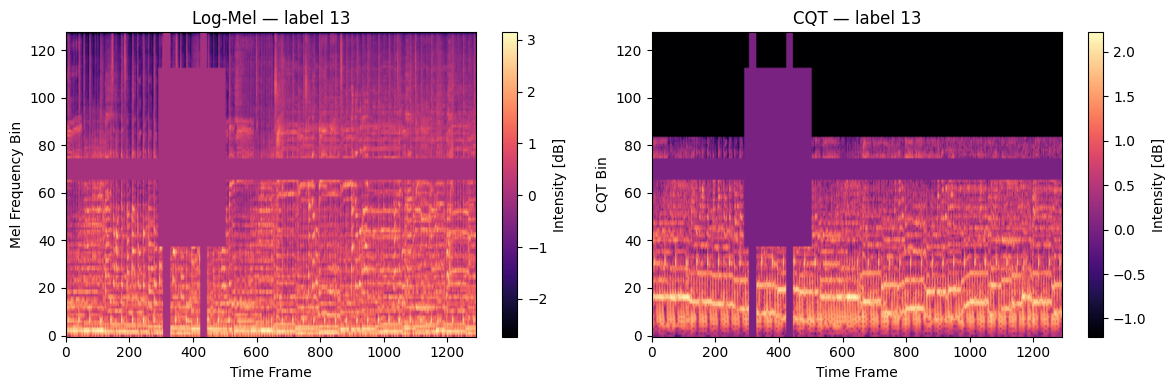

Label: 0 — Shape: torch.Size([2, 128, 1292])
torch.Size([1, 768])


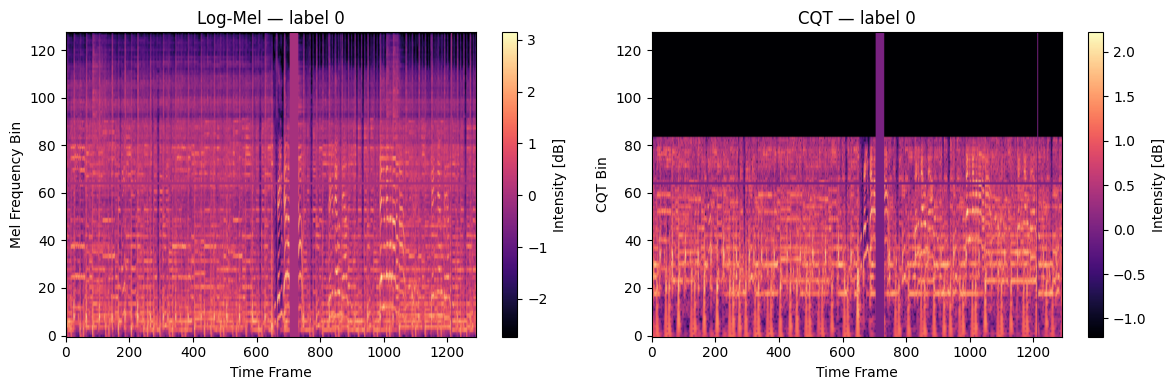

In [10]:
# These will be transformed (normalized)
def visualize_dataset(loader, ds):
    data = next(iter(loader))
    inputs, lyrics, labels = data
    N = 2

    for i in range(N):
        input = inputs[i]   # (2, 128, 1292), (32, 1, 1, 768)
        label = labels[i].item()
        print(f"Label: {label} — Shape: {input.shape}")

        print(lyrics[i].shape)

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        titles = [('Log-Mel', 'Mel Frequency Bin'), ('CQT', 'CQT Bin')]

        for ax, channel, (title, ylabel) in zip(axes, range(2), titles):
            im = ax.imshow(input[channel], origin='lower', aspect='auto', cmap='magma')
            ax.set_ylabel(ylabel)
            ax.set_xlabel('Time Frame')
            ax.set_title(f'{title} — label {label}')
            fig.colorbar(im, ax=ax, label='Intensity [dB]')

        plt.tight_layout()
        plt.show()

visualize_dataset(train_loader, train_ds)

## 5. Create the Network

### Model
Since there are 2 separate inputs (spectrogram and lyric embeddings) a custom model.

In [11]:
class MultiModalClassifier(torch.nn.Module):
    def __init__(self, num_classes: int, text_embed_dim: int = 768):
        super().__init__()

        # Audio Branch - ResNet18 with custom head
        resnet = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
        resnet.conv1 = torch.nn.Conv2d(2, 64, kernel_size=7, stride=2, padding=3, bias=False)

        audio_feat_dim = resnet.fc.in_features
        
        resnet.fc = torch.nn.Sequential(
            torch.nn.Dropout(),
            torch.nn.Linear(audio_feat_dim, len(genre_map))
        )

        self.audio_branch = torch.nn.Sequential(*list(resnet.children())[:-1])

        text_feat_dim = 128

        self.text_branch = torch.nn.Sequential(
            torch.nn.Linear(text_embed_dim, 256),
            torch.nn.ReLU(),
            torch.nn.Dropout(p=0.3),
            torch.nn.Linear(256, text_feat_dim)
        )

        self.classifier = torch.nn.Sequential(
            torch.nn.Linear(audio_feat_dim + text_feat_dim, 256),
            torch.nn.ReLU(),
            torch.nn.Dropout(),
            torch.nn.Linear(256, num_classes)
        )

    def forward(self, spectrogram: torch.Tensor, lyric_embedding: torch.Tensor):
        audio_feat = self.audio_branch(spectrogram).flatten(1) # (batch, 512)

        text_feat = self.text_branch(lyric_embedding).flatten(1) # (batch, 128)

        combined = torch.cat([audio_feat, text_feat], dim=1) # (batch, 640)

        return self.classifier(combined) # (batch, num_classes)

## 6. Train the Network

### Testing and Accuracy Functions

In [12]:
def check_accuracy(loader: DataLoader, model: any, loss_fn: any) -> tuple[float, float, list[float]]:
    """
    Runs the given model on the given dataloader.

    Returns:
        Tuple[accuracy, loss, prediction heatmap]
    """
    print("Checking Accuracy")
    model = model.to(device=device)
    num_correct = num_samples = 0
    model.eval()
    # NxN predicted values for heatmap
    heatmap = np.array([[0]*len(genre_map) for _ in range(len(genre_map))])
    with torch.no_grad():
        epoch_loss = 0
        for spectrogram, lyrics, label in loader:
            spectrogram = spectrogram.to(device=device)
            lyrics = lyrics.to(device=device)
            y = label.to(device=device)

            scores = model(spectrogram, lyrics)
            loss = loss_fn(scores, y)
            _, predictions = scores.max(1)
            
            heatmap[predictions.cpu(), y.cpu()] += 1
            num_correct += (predictions == y).sum()
            num_samples += predictions.size(0)
            epoch_loss += loss.item()
        print(f"Got {num_correct} / {num_samples} with accuracy {float(num_correct)/float(num_samples)*100:.2f}%")
        print(f"Validation Loss: {float(epoch_loss)/float(len(loader)):.4f}")
    return float(num_correct)/float(num_samples), float(epoch_loss)/float(len(loader)), heatmap

def train_model(train_loader, valid_loader, model, optimizer, scheduler, loss_fn, epochs) -> tuple[list[float], list[float], list[float]]:
    model = model.to(device=device)
    train_accuracy = []
    losses = []
    validation_acc = []
    val_losses = []
    for e in range(epochs):
        epoch_loss = 0.0
        num_right = 0
        num_total = 0
        for spectrogram, lyrics, label in tqdm(train_loader, total=len(train_loader), desc="Batch"):
            model.train()
            spectrogram = spectrogram.to(device=device)
            lyrics = lyrics.to(device=device)
            y = label.to(device=device)

            score = model(spectrogram, lyrics)
            loss = loss_fn(score, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            

            actual = torch.argmax(score, dim=1)
            
            num_right += sum([1 if actual[i] == y[i] else 0 for i in range(len(y))])
            num_total += y.size(0)

            epoch_loss += loss.item()
        avg_loss = epoch_loss / len(train_loader)

        print(f"Epoch {e+1}/{epochs}, Loss: {avg_loss:.4f}, Accuracy: {num_right}/{num_total} ({float(num_right)/float(num_total)*100:.2f}%)")
        val_acc, val_loss, _ = check_accuracy(valid_loader, model, loss_fn)
        print()
        scheduler.step()
        validation_acc.append(val_acc)
        losses.append(avg_loss)
        val_losses.append(val_loss)
        train_accuracy.append(float(num_right)/float(num_total))
    return train_accuracy, losses, validation_acc, val_losses

### Training
Implemented 2 phase training due to constant validation accuracy. This hopefully allows the new head to learn before adjusting the ResNet-18 body.

In [13]:
# Set device
model = MultiModalClassifier(len(genre_map)).to(device=device)
for param in model.audio_branch.parameters():
    param.requires_grad = False
for param in model.text_branch.parameters():
    param.requires_grad = True
for param in model.classifier.parameters():
    param.requires_grad = True
loss_fn = torch.nn.CrossEntropyLoss()
epochs_head = 5
epochs = 7

# Define functions and values to be used for training
optimizer_head = torch.optim.Adam(
    filter(lambda p: p.requires_grad==True, model.parameters()), 
    lr=1e-4,
    weight_decay=1e-3
)

scheduler_head = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_head,
    T_max=epochs_head,
    eta_min=1e-6
)
torch.cuda.empty_cache()
# Train the model
train_accuracy_head, losses_head, validation_acc_head, val_loss_head = train_model(train_loader, val_loader, model, optimizer_head, scheduler_head, loss_fn, epochs_head)

for param in model.audio_branch.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(
    [
        {'params': model.audio_branch.parameters(), 'lr':1e-5},
        {'params': model.text_branch.parameters(), 'lr':1e-4},
        {'params': model.classifier.parameters(), 'lr':1e-4}
    ],
    weight_decay=1e-3
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=epochs,
    eta_min=1e-6
)
torch.cuda.empty_cache()
# Train the model
train_accuracy, losses, validation_acc, val_loss = train_model(train_loader, val_loader, model, optimizer, scheduler, loss_fn, epochs,)

Batch: 100%|██████████| 423/423 [03:28<00:00,  2.03it/s]


Epoch 1/5, Loss: 1.5973, Accuracy: 6983/13512 (51.68%)
Checking Accuracy
Got 1086 / 1704 with accuracy 63.73%
Validation Loss: 1.2575



Batch: 100%|██████████| 423/423 [02:06<00:00,  3.35it/s]


Epoch 2/5, Loss: 1.3589, Accuracy: 7961/13512 (58.92%)
Checking Accuracy
Got 1106 / 1704 with accuracy 64.91%
Validation Loss: 1.1779



Batch: 100%|██████████| 423/423 [02:06<00:00,  3.34it/s]


...

Epoch 5/7, Loss: 0.8488, Accuracy: 10030/13512 (74.23%)
Checking Accuracy
Got 1285 / 1704 with accuracy 75.41%
Validation Loss: 0.8496



Batch: 100%|██████████| 423/423 [03:12<00:00,  2.19it/s]


Epoch 6/7, Loss: 0.8329, Accuracy: 10105/13512 (74.79%)
Checking Accuracy
Got 1274 / 1704 with accuracy 74.77%
Validation Loss: 0.8499



Batch: 100%|██████████| 423/423 [03:14<00:00,  2.18it/s]


Epoch 7/7, Loss: 0.8175, Accuracy: 10207/13512 (75.54%)
Checking Accuracy
Got 1278 / 1704 with accuracy 75.00%
Validation Loss: 0.8470



### Visualize Training Results

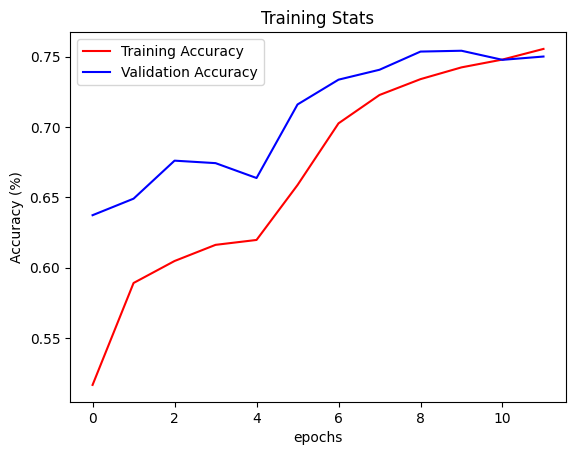

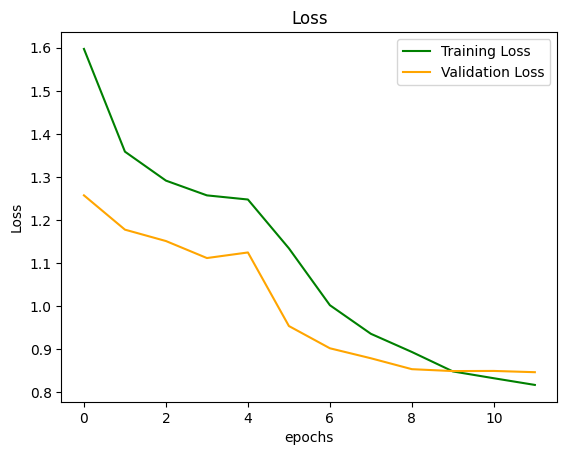

In [14]:
train_accuracy, losses, validation_acc
plt.plot(train_accuracy_head + train_accuracy, label="Training Accuracy", color='red')
plt.plot(validation_acc_head + validation_acc, label="Validation Accuracy", color='blue')
plt.title("Training Stats")
plt.xlabel("epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.show()
plt.plot(losses_head + losses, label="Training Loss", color='green')
plt.plot(val_loss_head + val_loss, label="Validation Loss", color='orange')
plt.title("Loss")
plt.xlabel("epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

## 7. Test the Network

In [15]:
train_acc, train_loss, heatmap = check_accuracy(test_loader, model, loss_fn)

Checking Accuracy
Got 1276 / 1772 with accuracy 72.01%
Validation Loss: 1.0167


### Confusion Matrix

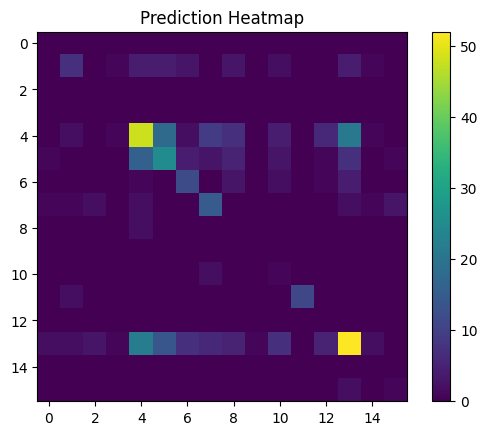

In [17]:
plt.imshow(heatmap, cmap='viridis', interpolation='nearest')
plt.colorbar()
plt.title("Prediction Heatmap")
plt.show()